# 01. Neural Network Classification with Tensorflow

**Neural Networks for Classification**

Classification is a supervised learning task where the goal is to assign input data to one or more predefined categories (classes). Neural networks excel at this because they can handle high-dimensional data like images, text, or audio.

- **How It Works:** The output layer typically uses a softmax activation function to convert raw scores into probabilities that sum to 1 (e.g., 80% chance it's a cat, 20% a dog). During training, the network is fed labeled data (e.g., images tagged as "cat" or "dog") and learns to map inputs to correct classes.

- **Neural Network with Classification**
    
    When a neural network is used to classify things, it’s called a neural network for classification.
        
    Here’s how it works:
        
    1. **Input data:** You feed the network some data (like an image of a cat).
    2. **Processing:** The hidden layers learn patterns from the data (like edges, shapes).
    3. **Output layer:** Instead of one number, it gives you probabilities for each class.

    - **Example: Image Classification**
    
        Imagine classifying handwritten digits (like in the MNIST dataset).
      
        A simple feedforward neural network might achieve 95%+ accuracy after training.
    
        - Input: A 28x28 pixel grayscale image flattened into 784 values.
        - Hidden Layers: Process features like edges or curves.
        - Output: 10 neurons, one for each digit (0-9). The neuron with the highest probability wins.

- **Types of Neural Networks for Classification:**

    - **Feedforward Neural Networks (MLPs):** Basic for tabular data (e.g., predicting email spam: yes/no).
    - **Convolutional Neural Networks (CNNs):** Great for images/videos (e.g., identifying objects in photos).
    - **Recurrent Neural Networks (RNNs/LSTMs):** For sequential data like text sentiment analysis.

**Common Use Cases**

- Handwriting recognition
- Email spam detection
- Image classification
- Voice recognition
- Medical diagnosis

### Architecture of a Classification Neural Network

**Quick Example:**

- Binary: Is this tumor malignant (1) or benign (0)?
- Multiclass: What digit is in this image? (0–9)

| **Component**         | **Binary Classification**                                             | **Multiclass Classification**                                         |
| --------------------- | --------------------------------------------------------------------- | --------------------------------------------------------------------- |
| **Input Layer**       | Typically a vector of features (e.g., shape `(batch_size, features)`) | Typically a vector of features (e.g., shape `(batch_size, features)`) |
| **Input Activation**  | No activation (raw input)                                             | No activation (raw input)                                             |
| **Hidden Layers**     | Dense layers with ReLU activation (or other activation functions)     | Dense layers with ReLU activation (or other activation functions)     |
| **Output Layer Size** | 1 neuron (for binary class prediction)                                | Number of neurons = number of classes (e.g., 3 neurons for 3 classes) |
| **Output Activation** | **Sigmoid** (outputs probability for class 1)                         | **Softmax** (outputs probabilities for each class)                    |
| **Output Range**      | 0 to 1 (probability of class 1)                                       | Each output: 0 to 1; All outputs sum to 1                             |
| **Loss Function**     | **Binary Cross-Entropy** (`binary_crossentropy`)                      | **Categorical Cross-Entropy** (`categorical_crossentropy`)            |
| **Label Format (y)**  | Single value: 0 or 1                                                  | One-hot encoded vector (e.g., [0,1,0]) or class index                 |
| **Optimizer**         | **Adam** (`adam`), **SGD** (`sgd`) or **RMSprop** (`rmsprop`)         | **Adam** (`adam`), **SGD** (`sgd`), or **RMSprop** (`rmsprop`)        |
| **Use Case Examples** | Spam vs. Not Spam, Disease vs. No Disease                             | Dog vs. Cat vs. Bird, Digit classification (0–9), Sentiment analysis  |


In [3]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [4]:
tf.__version__

'2.19.1'

### Data Viewing and Fitting

In [6]:
from sklearn.datasets import make_circles

In [8]:
# make 1000 examples
n_samples = 1000

# create circles
X, y = make_circles(n_samples,
                   noise=0.03,
                   random_state=42)

In [21]:
# view the 1st 3 data
X[:3], y[:3]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203]]),
 array([1, 1, 1]))

### Visualize the Data

In [17]:
circles = pd.DataFrame({
    "X0": X[:, 0], "X1": X[:, 1], "label": y
})

In [28]:
# check the 1st 3 data
circles.head(3)

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1


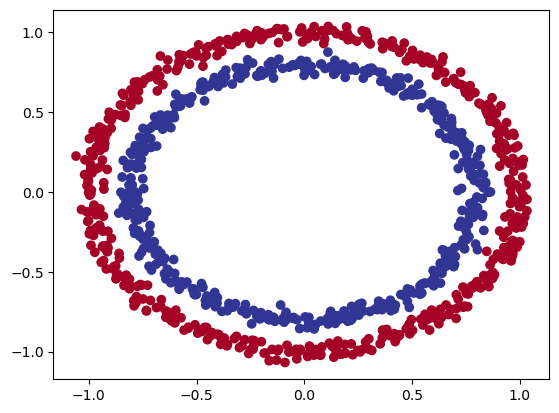

In [26]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

### Input and Output Shapes

In [29]:
# check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [30]:
# how many samples we're working
len(X), len(y)

(1000, 1000)

In [31]:
# view the first example of features and labels
X[0], y[0]

(array([0.75424625, 0.23148074]), 1)

### Building a Model

In [97]:
tf.random.set_seed(42)

# create the model with sequential
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# compile the model
model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
             optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
             metrics=["accuracy"])

# fit the model
history = model.fit(X, y, epochs=5)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4449 - loss: 0.9968
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4592 - loss: 0.7130 
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7174 - loss: 0.6019 
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8665 - loss: 0.3696 
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9357 - loss: 0.2586 


In [98]:
model.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9899 - loss: 0.0681  


[0.06241612881422043, 0.9929999709129333]

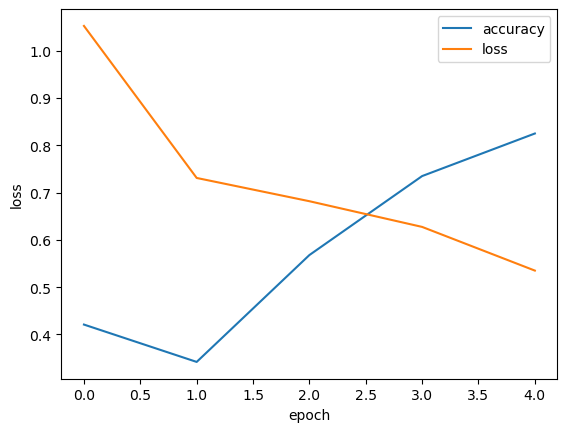

In [82]:
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend()

In [107]:
def plot_decision_bounday(model, X, y):
    """
    Plot the decision boundary created by a model predicting on X
    """

    # define the axis boundaries of the plot and create a meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                        np.linspace(y_min, y_max, 100))

    # create X value (we're going to make predictions on these)
    x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D arrays together

    # make predictions
    y_pred = model.predict(x_in)

    # check for multi-class
    if len(y_pred[0]) > 1:
        print("Doing multiclass classification")
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print("Binary classification")
        y_pred = np.round(y_pred).reshape(xx.shape)

    # plot the decision boundary
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step
Binary classification


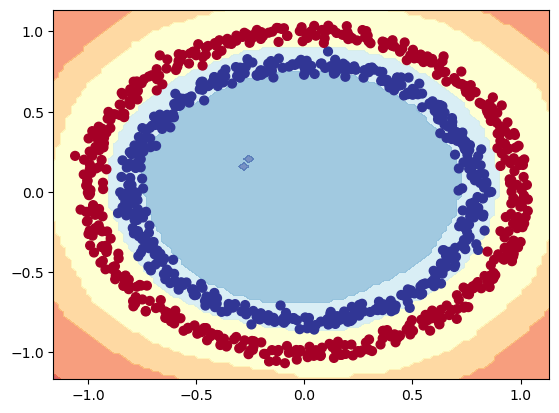

In [110]:
plot_decision_bounday(model, X, y)